In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix,classification_report

In [ ]:
(x_train,y_train),(x_test,y_test)=tf.keras.datasets.mnist.load_data()

In [ ]:
print('training images:',x_train.shape)
print('training labels:',y_train.shape)
print('testing images: ',x_test.shape)
print('testing labels: ',y_test.shape)

training images: (60000, 28, 28)
training labels: (60000,)
testing images:  (10000, 28, 28)
testing labels:  (10000,)


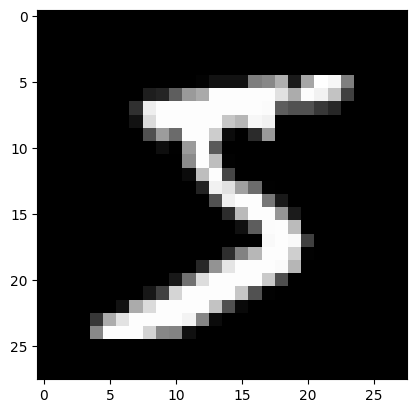

In [ ]:
plt.imshow(x_train[0],cmap='gray')

In [ ]:
x_train=x_train/255.0
x_test=x_test/255.0
print('min pixel: ',x_train.min())
print('max pixel: ',x_train.max())

min pixel:  0.0
max pixel:  1.0


In [ ]:
x_train=x_train.reshape(60000,784)
print(x_train[0])
print(y_train[:10])

[0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         

In [ ]:
model=tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28,28)),
    tf.keras.layers.Dense(128,activation='relu',input_shape=(784,)),
    tf.keras.layers.Dense(64,activation='relu'),
    tf.keras.layers.Dense(10,activation='softmax')
])


In [ ]:
from tensorflow.keras.datasets import mnist

In [ ]:
(x_train,y_train),(x_test,y_test)=mnist.load_data()
x_train=x_train/255.0
x_test=x_test/255.0

In [ ]:
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [ ]:
history=model.fit(x_train,y_train,epochs=10,validation_split=0.2,batch_size=30)

Epoch 1/10
1600/1600 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9235 - loss: 0.2649 - val_accuracy: 0.9588 - val_loss: 0.1397
Epoch 2/10
1600/1600 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9658 - loss: 0.1116 - val_accuracy: 0.9673 - val_loss: 0.1115
Epoch 3/10
1600/1600 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9766 - loss: 0.0769 - val_accuracy: 0.9707 - val_loss: 0.0931
Epoch 4/10
1600/1600 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9820 - loss: 0.0575 - val_accuracy: 0.9740 - val_loss: 0.0889
Epoch 5/10
1600/1600 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9859 - loss: 0.0447 - val_accuracy: 0.9720 - val_loss: 0.0968
Epoch 6/10
1600/1600 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9883 - loss: 0.0348 - val_accuracy: 0.9759 - val_loss: 0.0899
Epoch 7/10
1600/1600 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9906 - loss: 0.0288 - val_accuracy: 0.9743 - val_loss: 0.1017
Epoch 8/10
1600/1600 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9912 - loss: 0.0254 - 

In [ ]:
print(history.history.keys())

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


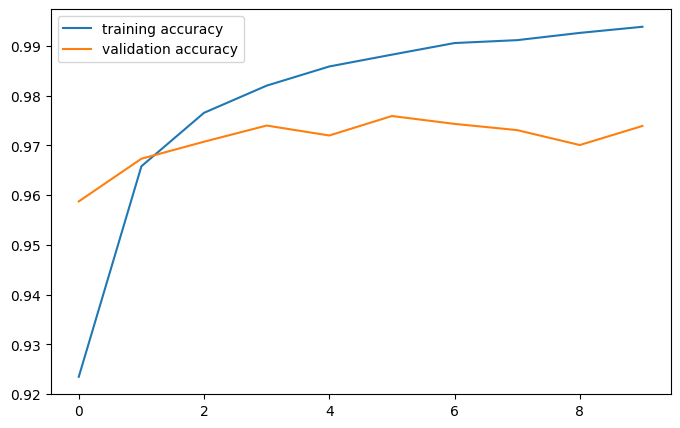

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'],label='training accuracy')
plt.plot(history.history['val_accuracy'],label='validation accuracy')
plt.legend()
plt.show()

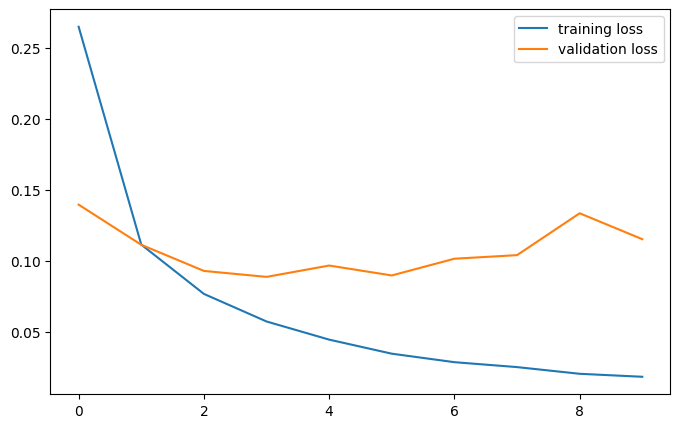

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'],label='training loss')
plt.plot(history.history['val_loss'],label='validation loss')
plt.legend()
plt.show()

In [ ]:
y_pred = model.predict(x_test)
print(y_pred)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
[[1.8077114e-13 5.0623711e-10 5.2665712e-11 ... 9.9999672e-01
  5.3841609e-10 1.7041446e-06]
 [1.7432914e-14 6.4504540e-08 9.9999982e-01 ... 5.7243090e-12
  5.2364702e-14 5.9914842e-17]
 [1.2360655e-09 9.9969006e-01 1.7578770e-04 ... 1.2333250e-04
  1.0235955e-05 1.1366841e-08]
 ...
 [5.4584841e-20 1.9312283e-09 3.9217927e-17 ... 5.3249744e-07
  1.4495487e-10 1.8685496e-04]
 [8.3125209e-16 4.4875282e-20 9.2460349e-20 ... 2.8047608e-12
  2.3312877e-10 2.0129235e-16]
 [2.4212915e-13 3.3137528e-16 2.0314614e-15 ... 2.2874064e-16
  1.1755633e-10 1.5872318e-20]]


In [ ]:
pred_label=np.argmax(y_pred_proba[0])
print('pred label:' ,pred_label)
print('actual value: ',y_test[0])

pred label: 7
actual value:  7


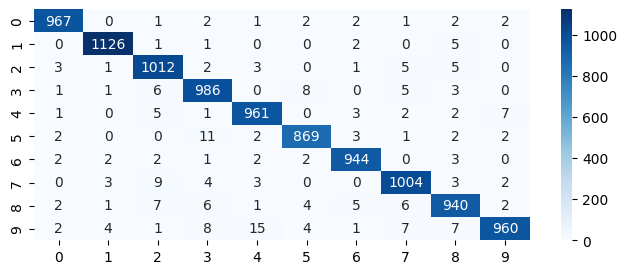

In [ ]:
y_pred=np.argmax(y_pred_proba,axis=1)

cm=confusion_matrix(y_test,y_pred)
plt.figure(figsize=(8,3))
import seaborn as sns
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')
plt.show()

In [ ]:
print('Classification report',classification_report(y_test,y_pred))

Classification report               precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.97      0.98      0.97      1032
           3       0.96      0.98      0.97      1010
           4       0.97      0.98      0.98       982
           5       0.98      0.97      0.98       892
           6       0.98      0.99      0.98       958
           7       0.97      0.98      0.98      1028
           8       0.97      0.97      0.97       974
           9       0.98      0.95      0.97      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



In [ ]:
model.save('mnist.keras')
print('saved')
load_model=tf.keras.models.load_model('mnist.keras')
print('loaded model')

saved
loaded model
